# Skewed-Target Regression

<div style="display: flex; gap: 10px; margin-bottom: 20px;">
  <a href="https://colab.research.google.com/github/OpenTabular/DeepTab/blob/main/docs/tutorials/notebooks/skewed_regression.ipynb" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
  <a href="https://github.com/OpenTabular/DeepTab/blob/main/docs/tutorials/notebooks/skewed_regression.ipynb" target="_blank">
    <img src="https://img.shields.io/badge/View%20on-GitHub-181717?logo=github&logoColor=white" alt="View on GitHub"/>
  </a>
</div>

Real regression targets are rarely well-behaved. Prices, durations, and counts are usually right-skewed, contain outliers, and depend on a mix of numerical and categorical drivers. This tutorial works through that harder setting end to end: a skewed target with informative categoricals, trained with an `FTTransformerRegressor`. Along the way we cover the techniques that actually move the needle for neural tabular regression: strong numerical encodings, target transformation, robust losses, Bayesian hyperparameter search, residual diagnostics, and a deployment-safe inference path.

## What You Will Learn

- How to train an `FTTransformerRegressor` and read its default `evaluate()` metrics.
- Why piecewise-linear encoding (`numerical_preprocessing="ple"`) helps transformer regressors.
- How to transform a skewed target without leaking statistics, and inverse-transform before reporting.
- When a robust loss (`nn.HuberLoss`) beats the default MSE, and how to pass it through `fit()`.
- How to run Bayesian hyperparameter search with `optimize_hparams()`.
- How to run residual diagnostics that expose subgroup failures a single R2 hides.
- How to compare architectures, track runs with `ObservabilityConfig`, and serve with `InferenceModel`.

## Setup

In [1]:
import numpy as np
import pandas as pd
import torch.nn as nn
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from deeptab.configs import (
    FTTransformerConfig,
    PreprocessingConfig,
    ResNetConfig,
    TabMConfig,
    TrainerConfig,
)
from deeptab.core.observability import ObservabilityConfig
from deeptab.core.reproducibility import set_seed
from deeptab.models import (
    FTTransformerRegressor,
    ResNetRegressor,
    TabMRegressor,
)

```{note}
For a quick demonstration these tutorials train with very low `max_epochs` and `patience` (5 and 2). Treat these as placeholders and choose values that match your own compute budget and problem. As a starting point, at least `max_epochs=100` and `patience=10` are recommended for meaningful results.
```

In [2]:
import logging
import warnings

# These tutorials use small synthetic datasets and short training runs, which
# surfaces a few non-actionable framework messages. Quieten them so the output
# stays focused on the tutorial; none of them affect correctness.
warnings.filterwarnings("ignore", message=".*n_quantiles.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*have no logger configured.*")
warnings.filterwarnings("ignore", message=".*lr_patience.*")
warnings.filterwarnings("ignore", message=".*Checkpoint directory.*")
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

## A Skewed, Mixed-Type Dataset

We build a synthetic dataset that looks like a pricing problem: twelve numerical drivers, two informative categorical columns (`region` and `grade`), and a strictly positive, right-skewed target produced by exponentiating a linear signal. The skew and the categorical multipliers are what make this harder than a textbook regression.

In [3]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
N = 5000

X_num, signal = make_regression(
    n_samples=N,
    n_features=12,
    n_informative=8,
    noise=8.0,
    random_state=RANDOM_STATE,
)
signal = (signal - signal.mean()) / signal.std()

# Two informative categoricals that scale the target multiplicatively
region = rng.choice(["north", "south", "east", "west"], size=N, p=[0.4, 0.3, 0.2, 0.1])
grade = rng.choice(["economy", "standard", "premium"], size=N, p=[0.5, 0.35, 0.15])
region_mult = pd.Series(region).map({"north": 1.0, "south": 1.2, "east": 0.8, "west": 1.5}).to_numpy()
grade_mult = pd.Series(grade).map({"economy": 0.7, "standard": 1.0, "premium": 1.6}).to_numpy()

# Strictly positive, right-skewed target (think: price)
y = np.exp(0.9 * signal + 2.0) * region_mult * grade_mult

X = pd.DataFrame(X_num, columns=[f"num_{i}" for i in range(X_num.shape[1])])
X["region"] = region   # string columns; DeepTab infers them as categorical
X["grade"] = grade

print(f"target skew: {pd.Series(y).skew():.2f}")
print(pd.Series(y).describe()[["mean", "50%", "max"]])

target skew: 5.04
mean     11.283886
50%       6.932112
max     283.616862
dtype: float64


## Reproducibility and Shared Configuration

`set_seed` controls weight initialisation, dropout, and DataLoader shuffling across CPU, CUDA, and MPS. Call it before each `fit()` and pass the same `random_state` so every model below sees an identical split and initialisation.

`numerical_preprocessing="ple"` bins each numerical feature and encodes it as a piecewise-linear vector, giving attention-based models a much richer numerical representation than raw standardisation. Other strong options are `"quantile"` and `"splines"`.

In [4]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE)

print(f"Train: {len(y_train)}  |  Val: {len(y_val)}  |  Test: {len(y_test)}")

PREPROC = PreprocessingConfig(
    numerical_preprocessing="ple",   # piecewise-linear encoding of numericals
    n_bins=64,
    categorical_preprocessing="int", # integer codes feed the model's embeddings
)
TRAINER = TrainerConfig(
    max_epochs=5,
    batch_size=256,
    lr=2e-4,
    patience=2,
    weight_decay=1e-5,
    optimizer_type="AdamW",
)
FIT_KWARGS = dict(X_val=X_val, y_val=y_val, random_state=RANDOM_STATE)

Train: 3500  |  Val: 750  |  Test: 750


## Helper: report

A small helper keeps the metrics consistent. RMSE is reported in the target's original units; we will always convert predictions back to those units before scoring.

In [5]:
def report(y_true, y_pred, label=""):
    metrics = {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }
    if label:
        print(f"{label:26s}  RMSE={metrics['rmse']:8.3f}  MAE={metrics['mae']:8.3f}  R2={metrics['r2']:.4f}")
    return metrics


results = {}

## Baseline: Raw Target, Default Loss

First, train directly on the raw skewed target with the default MSE loss. This is the number to beat. Regression metrics answer different questions: RMSE emphasises large errors, MAE is more robust to outliers, and R2 is scale-normalised but can mask subgroup failures. Report at least two of them.

In [6]:
set_seed(RANDOM_STATE)

baseline = FTTransformerRegressor(
    model_config=FTTransformerConfig(d_model=128, n_layers=4, n_heads=8, attn_dropout=0.1, ff_dropout=0.1),
    preprocessing_config=PREPROC,
    trainer_config=TRAINER,
    random_state=RANDOM_STATE,
)
baseline.fit(X_train, y_train, **FIT_KWARGS)

results["baseline (raw target)"] = report(y_test, baseline.predict(X_test), "baseline (raw target)")

Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 106.53it/s]
baseline (raw target)       RMSE=  13.706  MAE=   7.204  R2=-0.0538


In [7]:
# evaluate() returns the regression registry defaults when no metrics are given
print(baseline.evaluate(X_test, y_test))
# {"rmse": ..., "mae": ..., "r2": ...}

Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 106.07it/s]
{'rmse': 13.705773229918318, 'mae': 7.2042191247089455, 'r2': -0.053802867326562254}


## Transforming the Target

The single biggest lever for a skewed positive target is a log transform. It compresses the long right tail into a near-symmetric distribution that MSE can fit evenly. Because `log` is a fixed function with no fitted statistics, applying it introduces no leakage; we then exponentiate predictions back to the original units before scoring.

DeepTab does not transform the target for you. If your target can be zero or negative, use a learned transform such as `sklearn.preprocessing.PowerTransformer(method="yeo-johnson")`. Fit it on the training target only, then `transform` the validation target and `inverse_transform` predictions. Fitting it on the full target before splitting leaks test information into training.

In [8]:
y_train_log = np.log(y_train)
y_val_log = np.log(y_val)

set_seed(RANDOM_STATE)
log_model = FTTransformerRegressor(
    model_config=FTTransformerConfig(d_model=128, n_layers=4, n_heads=8, attn_dropout=0.1, ff_dropout=0.1),
    preprocessing_config=PREPROC,
    trainer_config=TRAINER,
    random_state=RANDOM_STATE,
)
log_model.fit(X_train, y_train_log, X_val=X_val, y_val=y_val_log, random_state=RANDOM_STATE)

pred = np.exp(log_model.predict(X_test))   # back to original units
results["log-target"] = report(y_test, pred, "log-target")

Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 107.86it/s]
log-target                  RMSE=  11.992  MAE=   5.347  R2=0.1933


## A Robust Loss for Outliers

Even after a log transform, a handful of records can sit far from the trend. MSE penalises those residuals quadratically and lets them dominate the gradient. `nn.HuberLoss` is quadratic for small residuals and switches to linear beyond a threshold `delta`, so large outliers pull less. The default regression loss is `nn.MSELoss`; you swap it by passing any `nn.Module` to `fit(loss_fct=...)`. `delta` is expressed in the units the model trains on, which here is log-space: start near `1.0` and lower it to make the loss more robust, or raise it to behave more like MSE.

In [9]:
set_seed(RANDOM_STATE)
huber_model = FTTransformerRegressor(
    model_config=FTTransformerConfig(d_model=128, n_layers=4, n_heads=8, attn_dropout=0.1, ff_dropout=0.1),
    preprocessing_config=PREPROC,
    trainer_config=TRAINER,
    random_state=RANDOM_STATE,
)
huber_model.fit(
    X_train, y_train_log,
    X_val=X_val, y_val=y_val_log,
    loss_fct=nn.HuberLoss(delta=1.0),
    random_state=RANDOM_STATE,
)

pred = np.exp(huber_model.predict(X_test))
results["log-target + Huber"] = report(y_test, pred, "log-target + Huber")

Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 105.99it/s]
log-target + Huber          RMSE=  11.992  MAE=   5.347  R2=0.1933


## Hyperparameter Optimisation

`optimize_hparams()` runs Gaussian-process Bayesian optimisation (via `skopt.gp_minimize`) over a search space derived automatically from the model's config dataclass. It is far more sample-efficient than grid or random search, and epoch-level pruning abandons unpromising trials early. It writes the winning values straight back into `tuned.config`, so a final clean fit trains on the selected configuration.

Each trial trains a full model, so the search is the most expensive step here. Keep `time` small while prototyping, run the search on the training and validation splits only, and never expose the test set to it.

In [10]:
set_seed(RANDOM_STATE)
tuned = FTTransformerRegressor(
    model_config=FTTransformerConfig(),
    preprocessing_config=PREPROC,
    trainer_config=TrainerConfig(max_epochs=5, batch_size=256, patience=2),
    random_state=RANDOM_STATE,
)

best_hparams = tuned.optimize_hparams(
    X_train, y_train_log,
    X_val=X_val, y_val=y_val_log,
    time=15,                     # number of trials (must be at least 10)
    max_epochs=5,
    prune_by_epoch=True,         # prune trials by their loss at prune_epoch
    prune_epoch=2,
)
print("Best hyperparameters:", best_hparams)

Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Validation DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 104.32it/s]
Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'ca

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Validation DataLoader 0: 100%|██████████| 6/6 [00:00<00:00, 146.38it/s]
Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'ca

...

Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

In [11]:
set_seed(RANDOM_STATE)
tuned.fit(X_train, y_train_log, X_val=X_val, y_val=y_val_log, random_state=RANDOM_STATE)
results["tuned (HPO)"] = report(y_test, np.exp(tuned.predict(X_test)), "tuned (HPO)")

Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 79.85it/s] 
tuned (HPO)                 RMSE=   8.659  MAE=   3.344  R2=0.5794


## Residual Diagnostics

A single R2 can hide systematic errors in a subgroup. After training, inspect the residuals and break the score down by category. A residual mean far from zero signals bias (the model systematically over- or under-predicts); strong variation in per-segment R2 signals that a feature interaction is being missed, which is a cue to add features, raise capacity, or train a segment-aware model. An optional residual plot makes the same point visually.

In [12]:
pred = np.exp(log_model.predict(X_test))
resid = y_test - pred

print(f"residual mean: {resid.mean():.4f}   residual std: {resid.std():.4f}")

diag = X_test.assign(y_true=y_test, y_pred=pred)
for col in ["region", "grade"]:
    print(f"\nR2 by {col}:")
    for level, grp in diag.groupby(col, observed=True):
        print(f"  {level:10s}  R2={r2_score(grp['y_true'], grp['y_pred']):.3f}   n={len(grp)}")

Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 71.92it/s] 
residual mean: 3.5424   residual std: 11.4568

R2 by region:
  east        R2=0.203   n=133
  north       R2=0.209   n=313
  south       R2=0.211   n=230
  west        R2=0.106   n=74

R2 by grade:
  economy     R2=0.247   n=382
  premium     R2=-0.069   n=98
  standard    R2=0.165   n=270


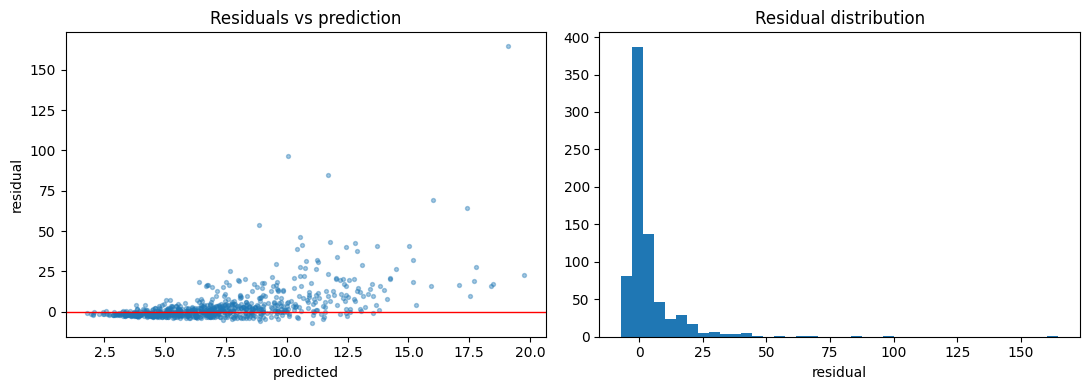

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(pred, resid, s=8, alpha=0.4)
ax1.axhline(0, color="red", lw=1)
ax1.set(xlabel="predicted", ylabel="residual", title="Residuals vs prediction")
ax2.hist(resid, bins=40)
ax2.set(xlabel="residual", title="Residual distribution")
plt.tight_layout()
plt.show()

## Comparing Architectures

With the data pipeline fixed, swapping the backbone is a one-line change. Here we compare FT-Transformer against TabM (an efficient MLP ensemble) and ResNet under the identical split, preprocessing, and log target. There is no universally best tabular architecture, so a comparison like this, run under one fixed pipeline, is the only reliable way to choose for your data.

In [14]:
architectures = {
    "FTTransformer": FTTransformerRegressor(
        model_config=FTTransformerConfig(d_model=128, n_layers=4),
        preprocessing_config=PREPROC, trainer_config=TRAINER, random_state=RANDOM_STATE,
    ),
    "TabM": TabMRegressor(
        model_config=TabMConfig(layer_sizes=[256, 256, 128], ensemble_size=16),
        preprocessing_config=PREPROC, trainer_config=TRAINER, random_state=RANDOM_STATE,
    ),
    "ResNet": ResNetRegressor(
        model_config=ResNetConfig(),
        preprocessing_config=PREPROC, trainer_config=TRAINER, random_state=RANDOM_STATE,
    ),
}

arch_results = {}
for name, estimator in architectures.items():
    set_seed(RANDOM_STATE)
    estimator.fit(X_train, y_train_log, **FIT_KWARGS)
    arch_results[name] = report(y_test, np.exp(estimator.predict(X_test)), name)

summary = pd.DataFrame(arch_results).T.sort_values("r2", ascending=False)
print(summary.to_string(float_format="{:.4f}".format))

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Nume

## Observability

Attach an `ObservabilityConfig` to record each run's hyperparameters, lifecycle events, and final metrics in one self-contained directory. This is invaluable when you sweep target transforms, losses, and architectures and want to compare runs afterwards instead of re-reading console logs. Each fit writes a tidy run directory whose `config.yaml` records the exact settings behind the metrics in `summary.json`.

Structured logging needs `structlog` (`pip install 'deeptab[logs]'`) and the TensorBoard tracker needs `tensorboard`. Drop `observability_config` to train silently, or see the [Observability guide](../core_concepts/observability) for MLflow, verbosity levels, and bringing your own logger.

In [15]:
obs = ObservabilityConfig(
    experiment_name="regression_fttransformer",
    structured_logging=True,
    log_to_file=True,
    verbosity=2,
    experiment_trackers=["tensorboard"],
)

set_seed(RANDOM_STATE)
tracked = FTTransformerRegressor(
    model_config=FTTransformerConfig(d_model=128, n_layers=4),
    preprocessing_config=PREPROC,
    trainer_config=TRAINER,
    observability_config=obs,
    random_state=RANDOM_STATE,
)
tracked.fit(X_train, y_train_log, **FIT_KWARGS)

2026-06-14 02:13:09 [info] run=2e1ad0ab  fit.started       model=FTTransformerRegressor  samples=3_500  features=14  seed=42
Numerical Feature: num_0, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: num_5, Info: {'preprocessi

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 4: 100%|██████████| 14/14 [00:00<00:00, 26.27it/s, v_num=d0ab, train_loss_step=0.535, val_loss=279.0, train_loss_epoch=0.554]
2026-06-14 02:13:13 [info] run=2e1ad0ab  train.completed   best_epoch=null  best_val_loss=278.5326  epochs_run=5  duration_min=0.0537
2026-06-14 02:13:13 [info] run=2e1ad0ab  fit.completed     status=success  model=FTTransformerRegressor  params=694_529  best_val_loss=278.5326  duration_min=0.0556


FTTransformerRegressor(model_config=FTTransformerConfig(head_layer_sizes=[]),
                       preprocessing_config=PreprocessingConfig(numerical_preprocessing='ple',
                                                                categorical_preprocessing='int',
                                                                n_bins=64,
                                                                feature_preprocessing=None,
                                                                use_decision_tree_bins=None,
                                                                binning_strategy=None,
                                                                task=None,
                                                                cat_cutoff=None,
                                                                treat_all_integers_as_numerical=None,
                                                                degree=None,
                                                                scaling_...
                                                    patience=2,
                                                    monitor='val_loss',
                                                    mode='min',
                                                    lr=0.0002,
                                                    lr_patience=10,
                                                    lr_factor=0.1,
                                                    weight_decay=1e-05,
                                                    optimizer_type='AdamW',
                                                    optimizer_kwargs=None,
                                                    scheduler_type='ReduceLROnPlateau',
                                                    scheduler_kwargs=None,
                                                    scheduler_monitor=None,
                                                    scheduler_interval='epoch',
                                                    scheduler_frequency=1,
                                                    no_weight_decay_for_bias_and_norm=False,
                                                    checkpoint_path='model_checkpoints'))

## Save and Load

Persist the fitted estimator as a single artifact. The recommended extension is `.deeptab`; the bundle carries the weights, fitted preprocessor, feature schema, and metadata, so a reloaded model predicts identically with no re-fitting.

In [16]:
log_model.save("regression_model.deeptab")

loaded = FTTransformerRegressor.load("regression_model.deeptab")
np.testing.assert_allclose(log_model.predict(X_test), loaded.predict(X_test), atol=1e-5)
print("Reload predictions match")

/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 102.03it/s]
Reload predictions match


## Production Inference with `InferenceModel`

For a service or batch job, load the artifact through `InferenceModel`. It exposes only `predict` and `validate_input`, so deployment code cannot accidentally call `fit()`, and it checks the incoming schema and re-orders columns to match training order before predicting.

The model was trained on `log(y)`, so `infer.predict()` returns log-space values. The inverse transform (`np.exp`) is part of the serving contract and must live in your deployment code. Forgetting it is the most common cause of "the model is wildly off in production" for transformed targets.

In [17]:
from deeptab import InferenceModel

infer = InferenceModel.from_path("regression_model.deeptab")
print(infer)


def predict_price(payload: dict) -> float:
    X = pd.DataFrame([payload])
    X_clean = infer.validate_input(X, allow_extra_columns=True)
    log_pred = infer.predict(X_clean)
    return float(np.exp(log_pred[0]))   # invert the log transform used in training


print(predict_price(X_test.iloc[0].to_dict()))

InferenceModel(task='regression', estimator='FTTransformerRegressor', n_features=14, features=['num_0', 'num_1', 'num_2', ...])


/Volumes/Research/Repositories/DeepTab/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


4.945943832397461


In [18]:
# Schema validation catches common pipeline mistakes before they reach the network.
# A dropped feature column is reported precisely:
X_bad = X_test.drop(columns=["num_0"])
try:
    infer.validate_input(X_bad)
except ValueError as exc:
    print(exc)

Input is missing 1 column(s) that were present during training: ['num_0'].


## Next Steps

- [Uncertainty quantification](uncertainty_quantification): predict full conditional distributions, not just point estimates
- [Advanced training](advanced_training): schedulers, callbacks, and fine-grained training control
- [Observability](../core_concepts/observability): lifecycle events, structured logging, and experiment tracking
- [Inference model](../core_concepts/inference): the deployment-safe prediction surface
- [Recommended configs](../model_zoo/recommended_configs): strong starting hyperparameters per model